In [36]:
# imports
import tensorflow as tf
import matplotlib.pyplot as plt


## Import Data

In [37]:
#import  data

IMG_SIZE = 224
BATCH_SIZE = 32

train_data = tf.keras.preprocessing.image_dataset_from_directory(
    "data/train",
    shuffle = True,
    image_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE
)

test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = "data/test",
    shuffle = True,
    image_size = (IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = "data/valid",
    shuffle = True,
    image_size = (IMG_SIZE,IMG_SIZE),
    batch_size = BATCH_SIZE
)

Found 2339 files belonging to 10 classes.
Found 50 files belonging to 10 classes.
Found 50 files belonging to 10 classes.


In [38]:
class_names = train_data.class_names
print(class_names)

['AFRICAN LEOPARD', 'CARACAL', 'CHEETAH', 'CLOUDED LEOPARD', 'JAGUAR', 'LIONS', 'OCELOT', 'PUMA', 'SNOW LEOPARD', 'TIGER']


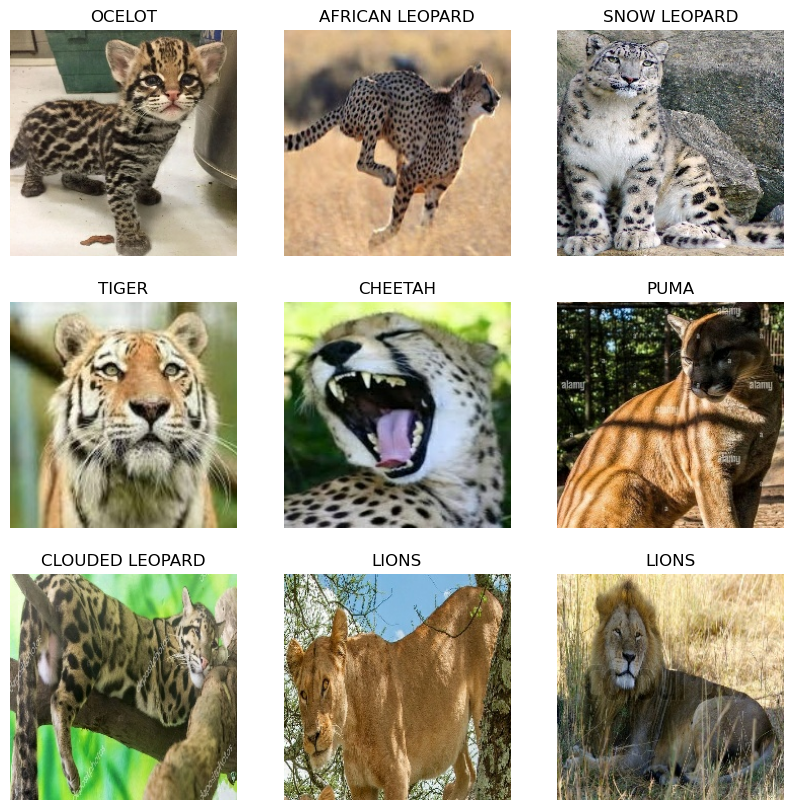

In [39]:
plt.figure(figsize = (10,10))
for image_batch, label_batch in train_data.take(1):
    for i in range(9):
        # print(image_batch[i].shape)
        ax = plt.subplot(3,3, i+1)
        plt.imshow(image_batch[i].numpy().astype('uint'))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')
        

## Preprocessing

Notes for Preprocessing:

- resizing - to ensure all images are of unifrom size
- normalization - adjusts intestity values
- noise reduction - for bluring/filtering/smoothing of backgrounds - will see if we use or not
- might need to do image augmentation
- data distrabution correction

Image Augmentation

In [40]:
train_generator = tf.keras.preprocessing.image.ImageDataGenerator(
    rescale=1.0/255,                # Rescale pixel values to [0, 1]
    rotation_range=20,              # Random rotation within 20 degrees
    width_shift_range=0.2,          # Random horizontal shift by 20% of image width
    height_shift_range=0.2,         # Random vertical shift by 20% of image height
    horizontal_flip=True,           # Random horizontal flipping
    fill_mode='nearest'             # Fill mode for new pixels after shifts/rotations
)

# data augmentation for testing
test_generator  = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255)  # Rescale pixel values to [0, 1]

# data augmentation for validation
valid_generator = tf.keras.preprocessing.image.ImageDataGenerator(rescale=1.0/255)  # Rescale pixel values to [0, 1]

train_augmented = train_generator.flow_from_directory(
    "data/train",                     # Path to the training data
    target_size=(IMG_SIZE, IMG_SIZE),  # Resize images to this size
    batch_size=BATCH_SIZE,           # Number of images in each batch
    seed=32,                         # Optional: Set a random seed for shuffling
    shuffle=True,                    # Shuffle the data during training
    class_mode='categorical'        # Mode for class labels (categorical for one-hot encoding)
)

# Create a generator for testing data
test_augmented = test_generator.flow_from_directory(
    "data/test",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode='categorical')


# Create a generator for validation data
valid_augmented = valid_generator.flow_from_directory(
    "data/valid",
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size = BATCH_SIZE,
    class_mode='categorical')


Found 2339 images belonging to 10 classes.
Found 50 images belonging to 10 classes.
Found 50 images belonging to 10 classes.
